In [ ]:
import os
import json
import numpy as np
import cv2

def create_color_map(classes):
    """
    Create a color map for visualization of semantic segmentation masks.

    Args:
        classes (list): List of class names

    Returns:
        dict: Mapping of class indices to BGR colors
    """
    # Predefined color palette (BGR format)
    color_palette = [
        [0, 0, 0],
        [27, 122, 0],
        [162, 115, 83],
        [110, 67, 38],
        [176, 176, 176]
    ]

    # Create color map dictionary
    color_map = {
        classes.index(cls): color
        for cls, color in zip(classes, color_palette[:len(classes)])
    }

    return color_map

def create_mask_from_labelme(json_path, image_size, classes):
    """
    Create a semantic segmentation mask from a LabelMe JSON annotation.

    Args:
        json_path (str): Path to the LabelMe JSON annotation file
        image_size (tuple): (height, width) of the image
        classes (list): List of class names in order of mask value

    Returns:
        numpy.ndarray: Semantic segmentation mask
    """
    # Initialize mask with background class (0)
    mask = np.zeros(image_size, dtype=np.uint8)

    # Read the JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Iterate through shapes in the annotation
    for shape in data.get('shapes', []):
        # Get the class label and polygon points
        label = shape['label']
        points = np.array(shape['points'], dtype=np.int32)

        # Find the class index (0 for background)
        try:
            class_index = classes.index(label)
        except ValueError:
            print(f"Warning: Class '{label}' not found in class list. Skipping.")
            continue

        # Create a mask for this specific shape
        shape_mask = np.zeros(image_size, dtype=np.uint8)
        cv2.fillPoly(shape_mask, [points], 255)

        # Set the mask to the corresponding class value
        mask[shape_mask == 255] = class_index

    return mask

def convert_labelme_to_masks(input_folder, output_folder, classes):
    """
    Convert all LabelMe JSON annotations in a folder to semantic segmentation masks.

    Args:
        input_folder (str): Path to the input folder with annotations and images
        output_folder (str): Path to save the output masks
        classes (list): List of class names in order of mask value
    """
    # Create output folders
    os.makedirs(output_folder, exist_ok=True)
    os.makedirs(os.path.join(output_folder, 'visualizations'), exist_ok=True)
    os.makedirs(os.path.join(output_folder, 'segmentation_class'), exist_ok=True)

    # Create color map
    color_map = create_color_map(classes)

    # Path to annotations and images
    annotations_path = os.path.join(input_folder, 'annotations')
    images_path = os.path.join(input_folder, 'images')

    # Iterate through annotation files
    for annotation_file in os.listdir(annotations_path):
        if not annotation_file.endswith('.json'):
            continue

        # Construct full paths
        json_path = os.path.join(annotations_path, annotation_file)

        # Find corresponding image
        image_name = os.path.splitext(annotation_file)[0]
        image_file = None
        for ext in ['.jpg', '.png', '.jpeg', '.tiff']:
            if os.path.exists(os.path.join(images_path, image_name + ext)):
                image_file = image_name + ext
                break

        if not image_file:
            print(f"No image found for {annotation_file}")
            continue

        # Read the image to get its size
        image_path = os.path.join(images_path, image_file)
        image = cv2.imread(image_path)

        # Create mask
        mask = create_mask_from_labelme(
            json_path,
            image_size=(image.shape[0], image.shape[1]),
            classes=classes
        )

        # Save index mask (original integer mask)
        index_mask_path = os.path.join(output_folder, 'segmentation_class', f'{image_name}.png')
        cv2.imwrite(index_mask_path, mask)

        # Create color visualization
        color_mask = np.zeros_like(image)
        for class_index, color in color_map.items():
            color_mask[mask == class_index] = color

        # Save color mask
        color_mask_path = os.path.join(output_folder, 'visualizations', f'{image_name}.png')
        cv2.imwrite(color_mask_path, color_mask)

        print(f"Masks saved for {image_name}")

# Example usage
input_folder = '/content/drive/MyDrive/road_dataset'
output_folder = '/content/drive/MyDrive/sitevision2_masks'
classes = ['_background_', 'Road', 'Excavated', 'Land', 'Cement']

convert_labelme_to_masks(input_folder, output_folder, classes)

Mask shape: (1920, 1920)
Mask dtype: uint8
Unique values in mask: [0 1 2 3 4]


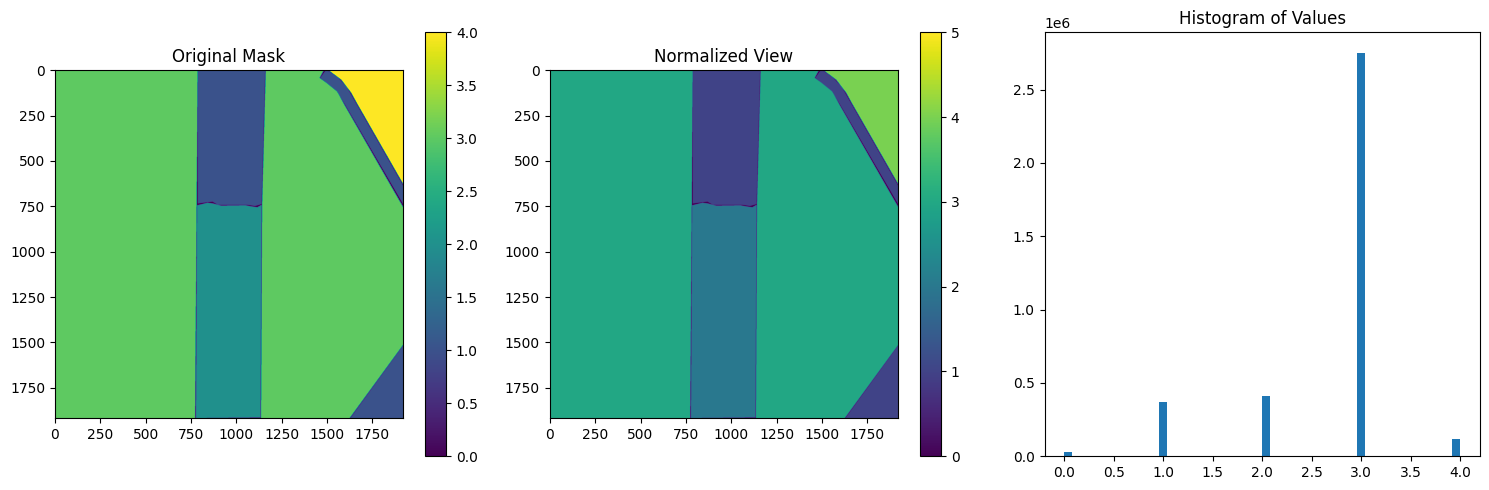

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def verify_mask(mask_path):
    """
    Load and analyze a mask file to verify its content
    """
    # Read the mask
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    # Print basic information
    print(f"Mask shape: {mask.shape}")
    print(f"Mask dtype: {mask.dtype}")
    print(f"Unique values in mask: {np.unique(mask)}")

    # Visualize the mask in different ways
    plt.figure(figsize=(15, 5))

    # Original mask
    plt.subplot(131)
    plt.imshow(mask)
    plt.title('Original Mask')
    plt.colorbar()

    # Normalize to see full range
    plt.subplot(132)
    plt.imshow(mask, vmin=0, vmax=5)  # Assuming 5 classes (0-4)
    plt.title('Normalized View')
    plt.colorbar()

    # 3D surface plot to see values clearly
    plt.subplot(133)
    plt.hist(mask.ravel(), bins=50)
    plt.title('Histogram of Values')

    plt.tight_layout()
    plt.show()

mask_path = '/content/drive/MyDrive/road_dataset/dataset/segmentation_class/1732963292137.png'
verify_mask(mask_path)